## Introduction

In this project I will create a model that will forecast the energy consumption of the grid network with a 7 day window. I will first train a model on the DAYTON.csv dataset, then evaulate this on other companies track records to see how the model generalizes. I will use the Mean Squared Error as my error metric.

## Importing libraries

In [1]:
# basics
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

# preprocessing
from sklearn.preprocessing import MinMaxScaler

# metrics
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

## Preprocessing

First I will check whether there are missing values or not. If there is I need to impute them with the timestep t-1 and t+1.

In [2]:
dayton = pd.read_csv("data/DAYTON_hourly.csv")
dayton = dayton.drop(columns="Datetime")

In [3]:
dayton.isna().sum()

DAYTON_MW    0
dtype: int64

Luckily there were no missing values, so I will create the train, validation and test splits from the original dataset.

In [4]:
n = len(dayton)

train_df = dayton.iloc[:int(n*0.7)]
val_df = dayton.iloc[int(n*0.7):int(n*0.85)]
test_df = dayton.iloc[int(n*0.85):]

scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(train_df)
valid_scaled = scaler.transform(val_df)
test_scaled = scaler.transform(test_df)

## 1. Predicting the next day consumption Seq2Vec

I will use a window size of 50. Each record is a observation every hour, so 50 hours covers the day before and 2 days before.

In [5]:
# creating the df objects
window = 50

train_df = tf.keras.utils.timeseries_dataset_from_array(
        data=train_scaled,            # get data from this dataset
        targets=train_scaled[window:], # target comes after 50th step
        sequence_length=window,   # each window will have 50 steps
        sequence_stride=1,        # move the window by 1
        shuffle=True,               
        batch_size=32
)

valid_df = tf.keras.utils.timeseries_dataset_from_array(
        data=valid_scaled[:-1],            
        targets=valid_scaled[window:], 
        sequence_length=window,   
        sequence_stride=1,
        shuffle=False,               
        batch_size=32
)

test_df = tf.keras.utils.timeseries_dataset_from_array(
        data=test_scaled[:-1],            
        targets=test_scaled[window:], 
        sequence_length=window,   
        sequence_stride=1,
        shuffle=False,               
        batch_size=32
)

### Baseline model - Naive forecast - MSE 0.00122

The baseline model is here for comparison. How much better can I build a model when it is compared with Naive Forecast. This rule works by predicting the next days` consumption to be the current days consumption.
- Prediction: t+1 = t

In [6]:
y_true = []
y_pred_naive = []

for x_batch, y_batch in valid_df:
    last_step = x_batch[:, -1, 0].numpy()

    y_pred_naive.extend(last_step)
    y_true.extend(y_batch.numpy().flatten())

naive_mse = np.mean((np.array(y_true) - np.array(y_pred_naive)) ** 2)
print("MSE: ",naive_mse)

MSE:  0.0012217728355270769


2026-09-16 08:04:47.035406: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


### Linear model - MSE 0.0145 | 1188% error increase compared to baseline 

This model breaks the previous model`s simple assumption. It tries to find the best coefficent and bias to fit the line to the electricity consumption. However in this problem set it performs worse than the baseline since the 1 timestep prediction window favors the baseline model more. When it comes to 7-day prediction window linear model should surpass the baseline model.

In [7]:
linear_model = keras.models.Sequential([
    keras.layers.Input(shape=(50,1)),
    keras.layers.Dense(1)
])

linear_model.compile(loss="mse", optimizer="adam")

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    patience=5,
    factor=0.5,
    verbose=1,
    min_lr=1e-6
)
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10
)

linear_model.fit(train_df, validation_data=valid_df, epochs=50, callbacks=[reduce_lr, early_stop])

Epoch 1/50


2652/2652 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - loss: 0.0481 - val_loss: 0.0172 - learning_rate: 0.0010
Epoch 2/50
2652/2652 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - loss: 0.0170 - val_loss: 0.0170 - learning_rate: 0.0010
Epoch 3/50
2652/2652 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - loss: 0.0170 - val_loss: 0.0171 - learning_rate: 0.0010
Epoch 4/50
2652/2652 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - loss: 0.0170 - val_loss: 0.0170 - learning_rate: 0.0010
Epoch 5/50
2652/2652 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - loss: 0.0170 - val_loss: 0.0170 - learning_rate: 0.0010
Epoch 6/50
2652/2652 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - loss: 0.0170 - val_loss: 0.0170 - learning_rate: 0.0010
Epoch 7/50
2621/2652 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0170
Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
2652/2652 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - loss: 0.0170 - val_loss: 0.0170 - learning_rate: 0.0010
Epoch 8/50
2652/2652 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - loss: 0.0170 - val_loss: 0.0170 - lea

567/567 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
567/567 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0150


(3000.0, 3400.0)

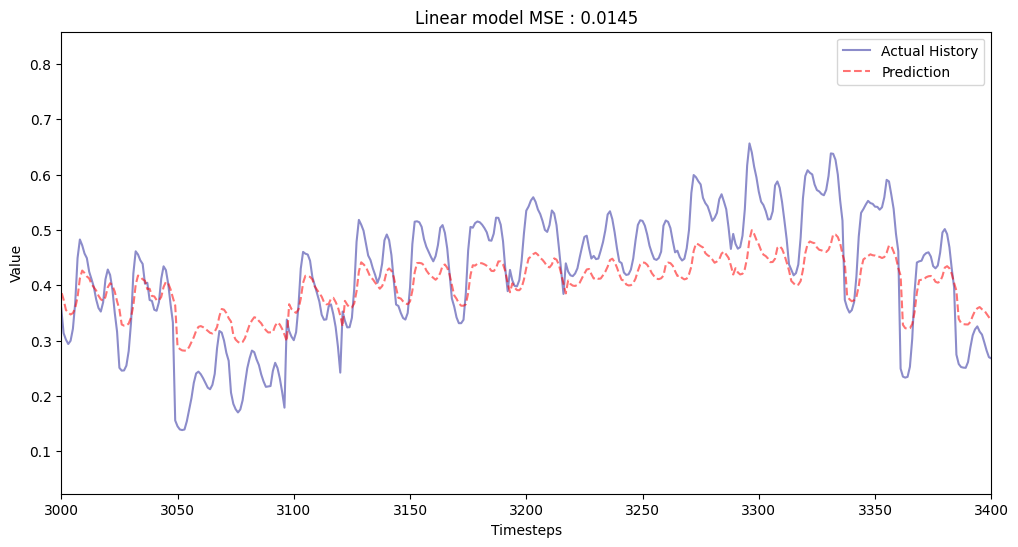

In [8]:
# Squeeze or select the first prediction window: shape becomes (50,)
y_pred = linear_model.predict(test_df)
mse1 = round(linear_model.evaluate(test_df),4)
y_linear_series = y_pred[:, -1, :].flatten()
steps = np.arange(50, len(y_pred)+50, 1)

plt.figure(figsize=[12, 6])
plt.plot(test_scaled, label="Actual History", color="darkblue", alpha=0.45)
plt.plot(steps, y_linear_series, "r--", label="Prediction", alpha=0.55)
plt.legend()
plt.title(f"Linear model MSE : {mse1}")
plt.xlabel("Timesteps")
plt.ylabel("Value")
plt.xlim(3000, 3400)


### Simple RNN model - MSE 0.0003 | -75.4 % error compared to baseline

The RNN model uses the current input and the previous output from the RNN model, which is called hidden state. Altough it remembers the previous output, it can not understand long term patterns.

In [9]:
model2 = keras.models.Sequential([
    keras.layers.Input(shape=(None,1)),
    keras.layers.SimpleRNN(32),
    keras.layers.Dense(1)
])
model2.compile(loss="mse", optimizer="adam")

model2.fit(train_df, validation_data=valid_df, epochs=20, callbacks=[early_stop, reduce_lr])

Epoch 1/20
2652/2652 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.0041 - val_loss: 4.1433e-04 - learning_rate: 0.0010
Epoch 2/20
2652/2652 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 4.1437e-04 - val_loss: 4.0402e-04 - learning_rate: 0.0010
Epoch 3/20
2652/2652 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 4.0744e-04 - val_loss: 4.0916e-04 - learning_rate: 0.0010
Epoch 4/20
2652/2652 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 3.9743e-04 - val_loss: 4.0901e-04 - learning_rate: 0.0010
Epoch 5/20
2652/2652 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 3.9095e-04 - val_loss: 4.1560e-04 - learning_rate: 0.0010
Epoch 6/20
2650/2652 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3.7950e-04
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
2652/2652 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 3.7949e-04 - val_loss: 3.7867e-04 - learning_rate: 0.0010
Epoch 7/20
2652/2652 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 3.4284e-04 - val_loss: 3.5074e-04 - learning_rate: 5.0000e-04
Epoch 8/20
2652/2652 ━

567/567 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
567/567 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 2.5755e-04


(0.0, 500.0)

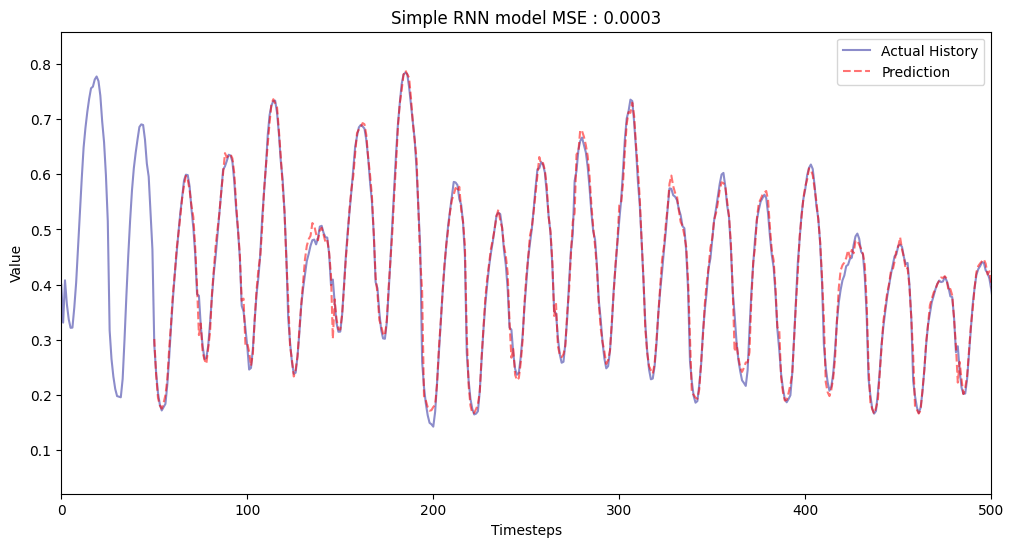

In [10]:
y_pred = model2.predict(test_df)
mse2 = round(model2.evaluate(test_df),4)
y_linear_series = y_pred.flatten()
steps = np.arange(50, len(y_pred)+50, 1)

plt.figure(figsize=[12, 6])
plt.plot(test_scaled, label="Actual History", color="darkblue", alpha=0.45)
plt.plot(steps, y_linear_series, "r--", label="Prediction", alpha=0.55)
plt.legend()
plt.title(f"Simple RNN model MSE : {mse2}")
plt.xlabel("Timesteps")
plt.ylabel("Value")
plt.xlim(0, 500)

In [11]:
mean_absolute_percentage_error(test_scaled[50:], y_linear_series)

0.03311263743539476

### LSTM model - MSE 0.0003

LSTM fixes RNN simplicity. It includes long and short term memory cell which are capable of remembering longer sequences. This helps the model to better fit to seasonalities and trends.

In [12]:
model3 = keras.models.Sequential([
    keras.layers.Input(shape=[None, 1]),
    keras.layers.LSTM(32),
    keras.layers.Dense(1)
])
model3.compile(loss="mse", optimizer="adam")
model3.fit(train_df, validation_data=valid_df, epochs=20, callbacks=[early_stop, reduce_lr])

Epoch 1/20
2652/2652 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - loss: 0.0084 - val_loss: 8.0052e-04 - learning_rate: 0.0010
Epoch 2/20
2652/2652 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - loss: 6.7730e-04 - val_loss: 5.9444e-04 - learning_rate: 0.0010
Epoch 3/20
2652/2652 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - loss: 5.6596e-04 - val_loss: 4.9682e-04 - learning_rate: 0.0010
Epoch 4/20
2652/2652 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - loss: 4.8078e-04 - val_loss: 4.7233e-04 - learning_rate: 0.0010
Epoch 5/20
2652/2652 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - loss: 4.3241e-04 - val_loss: 4.0198e-04 - learning_rate: 0.0010
Epoch 6/20
2652/2652 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - loss: 4.0083e-04 - val_loss: 4.1050e-04 - learning_rate: 0.0010
Epoch 7/20
2652/2652 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - loss: 3.7669e-04 - val_loss: 4.3014e-04 - learning_rate: 0.0010
Epoch 8/20
2652/2652 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - loss: 3.7013e-04 - val_loss: 3.6579e-04 - learning_rate: 0.0010
Epoch 9/20
2652/2652 ━━━━━━━━━━━━━━━

567/567 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
567/567 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2.6669e-04


(0.0, 500.0)

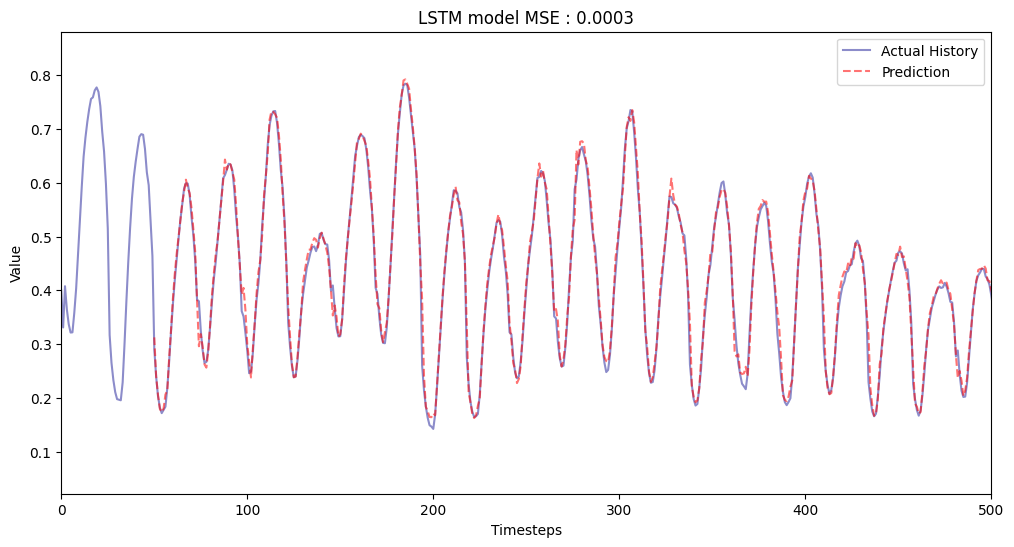

In [13]:
y_pred = model3.predict(test_df)
mse3 = round(model3.evaluate(test_df),4)
y_linear_series = y_pred.flatten()
steps = np.arange(50, len(y_pred)+50, 1)

plt.figure(figsize=[12, 6])
plt.plot(test_scaled, label="Actual History", color="darkblue", alpha=0.45)
plt.plot(steps, y_linear_series, "r--", label="Prediction", alpha=0.55)
plt.legend()
plt.title(f"LSTM model MSE : {mse3}")
plt.xlabel("Timesteps")
plt.ylabel("Value")
plt.xlim(0, 500)

### GRU model - MSE 0.0003

GRU is a simplified version of LSTM, it also has memory but its faster to train.

In [14]:
model4 = keras.models.Sequential([
    keras.layers.Input(shape=[None, 1]),
    keras.layers.GRU(32),
    keras.layers.Dense(1)
])
model4.compile(loss="mse", optimizer="adam")
model4.fit(train_df, validation_data=valid_df, epochs=20, callbacks=[early_stop, reduce_lr])

Epoch 1/20
2652/2652 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - loss: 0.0039 - val_loss: 8.6614e-04 - learning_rate: 0.0010
Epoch 2/20
2652/2652 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - loss: 7.0141e-04 - val_loss: 6.4382e-04 - learning_rate: 0.0010
Epoch 3/20
2652/2652 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - loss: 6.5778e-04 - val_loss: 5.4594e-04 - learning_rate: 0.0010
Epoch 4/20
2652/2652 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - loss: 5.2567e-04 - val_loss: 5.0756e-04 - learning_rate: 0.0010
Epoch 5/20
2652/2652 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - loss: 4.7163e-04 - val_loss: 4.3279e-04 - learning_rate: 0.0010
Epoch 6/20
2652/2652 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - loss: 4.3580e-04 - val_loss: 4.5283e-04 - learning_rate: 0.0010
Epoch 7/20
2652/2652 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - loss: 4.2236e-04 - val_loss: 4.0057e-04 - learning_rate: 0.0010
Epoch 8/20
2652/2652 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - loss: 4.0405e-04 - val_loss: 3.9339e-04 - learning_rate: 0.0010
Epoch 9/20
2652/2652 ━━━━━━━━━━━━━━━

567/567 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
567/567 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2.6217e-04


(0.0, 500.0)

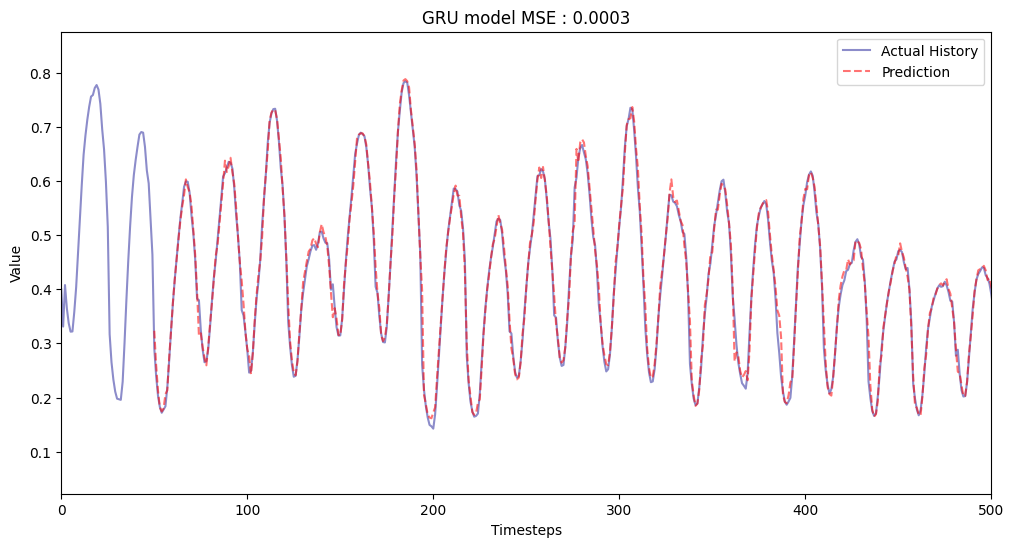

In [15]:
y_pred = model4.predict(test_df)
mse4 = round(model4.evaluate(test_df),4)
y_linear_series = y_pred.flatten()
steps = np.arange(50, len(y_pred)+50, 1)

plt.figure(figsize=[12, 6])
plt.plot(test_scaled, label="Actual History", color="darkblue", alpha=0.45)
plt.plot(steps, y_linear_series, "r--", label="Prediction", alpha=0.55)
plt.legend()
plt.title(f"GRU model MSE : {mse4}")
plt.xlabel("Timesteps")
plt.ylabel("Value")
plt.xlim(0, 500)

## 2. Predicting the next 7 day consumption -  Seq2Seq model
Reduced baseline error by 90.40% with the final model

First thing to change is the dataframe that we feed into the model. Now this object should allow the model to see 50 steps, and see the targets which are up until step 57. Also change the dense head to TimeDistributed(Dense(7)), this will train the model to output the next 7 days` forecast.

### Creating training, validation and test sets

In [16]:
steps_in = 50
steps_out = 7
total_window_size = steps_in + steps_out 

# 1. Create a dataset of 57-step windows
base_ds_train = tf.keras.utils.timeseries_dataset_from_array(
    data=train_scaled,
    targets=None,
    sequence_length=total_window_size,
    sequence_stride=7,
    shuffle=True,
    batch_size=32
)

base_ds_valid = tf.keras.utils.timeseries_dataset_from_array(
    data=valid_scaled,
    targets=None,
    sequence_length=total_window_size,
    sequence_stride=7,
    shuffle=False,
    batch_size=32
)

base_ds_test = tf.keras.utils.timeseries_dataset_from_array(
    data=test_scaled,
    targets=None,
    sequence_length=total_window_size,
    sequence_stride=7,
    shuffle=False,
    batch_size=32
)

# 2. Split each batch into X (first 50 steps) and y (next 7 steps)
def split_window(window):
    x = window[:, :steps_in, :]
    y = window[:, steps_in:, :]
    return x, y

train_ds = base_ds_train.map(split_window)
valid_ds = base_ds_valid.map(split_window)
test_ds = base_ds_test.map(split_window)

### Baseline model - Naive forecast - MSE 0.011029

When the model needs to predict the next 7 days from a 50-day window the naive model underperforms severly.

In [17]:
time_stride = 7
y_pred_naive = []
y_actual_naive = []

for x, y in test_ds:
    last_val = x[:, -1, :].numpy()
    naive_forecast = np.repeat(last_val, repeats=time_stride, axis=1)

    y_pred_naive.append(naive_forecast)
    y_actual_naive.append(y.numpy())

y_pred_naive = np.concatenate(y_pred_naive, axis=0).reshape(-1)  
y_actual_naive = np.concatenate(y_actual_naive, axis=0).reshape(-1)

2026-09-16 08:22:24.487126: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


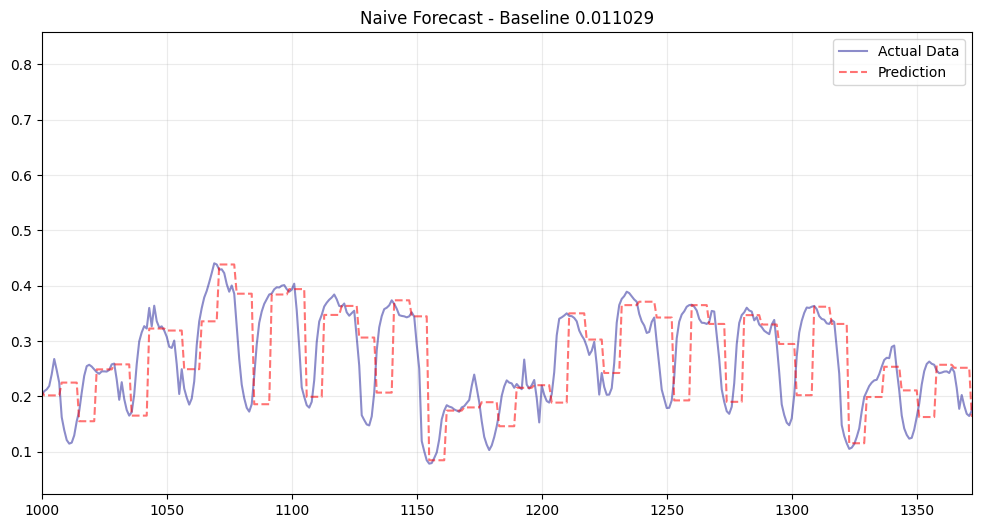

In [136]:
plt.figure(figsize=[12,6])

mse_naive = round(mean_squared_error(y_actual_naive, y_pred_naive),6)
plt.plot(y_actual_naive ,color="darkblue", alpha=0.45, label="Actual Data")
plt.plot(y_pred_naive, "r--", alpha=0.55, label="Prediction")
plt.title(f"Naive Forecast - Baseline {mse_naive}")
plt.xlim(1000,1372)
plt.grid(alpha=0.25)
plt.legend()

### Linear model - MSE 0.002302 | -79.12% error compared to baseline

In [19]:
linear_model2 = keras.models.Sequential([
    keras.layers.Input(shape=[50, 1]),
    keras.layers.Reshape((50,)),
    keras.layers.Dense(7)
])
linear_model2.compile(loss="mse", optimizer="adam")
linear_model2.fit(train_ds, validation_data=valid_ds, epochs=20, callbacks=[early_stop, reduce_lr])

Epoch 1/20
379/379 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0555 - val_loss: 0.0097 - learning_rate: 0.0010
Epoch 2/20
379/379 ━━━━━━━━━━━━━━━━━━━━ 0s 974us/step - loss: 0.0086 - val_loss: 0.0064 - learning_rate: 0.0010
Epoch 3/20
379/379 ━━━━━━━━━━━━━━━━━━━━ 0s 943us/step - loss: 0.0059 - val_loss: 0.0052 - learning_rate: 0.0010
Epoch 4/20
379/379 ━━━━━━━━━━━━━━━━━━━━ 0s 968us/step - loss: 0.0048 - val_loss: 0.0045 - learning_rate: 0.0010
Epoch 5/20
379/379 ━━━━━━━━━━━━━━━━━━━━ 0s 967us/step - loss: 0.0041 - val_loss: 0.0040 - learning_rate: 0.0010
Epoch 6/20
379/379 ━━━━━━━━━━━━━━━━━━━━ 0s 940us/step - loss: 0.0036 - val_loss: 0.0037 - learning_rate: 0.0010
Epoch 7/20
379/379 ━━━━━━━━━━━━━━━━━━━━ 0s 965us/step - loss: 0.0034 - val_loss: 0.0036 - learning_rate: 0.0010
Epoch 8/20
379/379 ━━━━━━━━━━━━━━━━━━━━ 0s 987us/step - loss: 0.0032 - val_loss: 0.0034 - learning_rate: 0.0010
Epoch 9/20
379/379 ━━━━━━━━━━━━━━━━━━━━ 0s 995us/step - loss: 0.0030 - val_loss: 0.0034 - learning_rate: 0

81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 787us/step - loss: 0.0022
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 851us/step


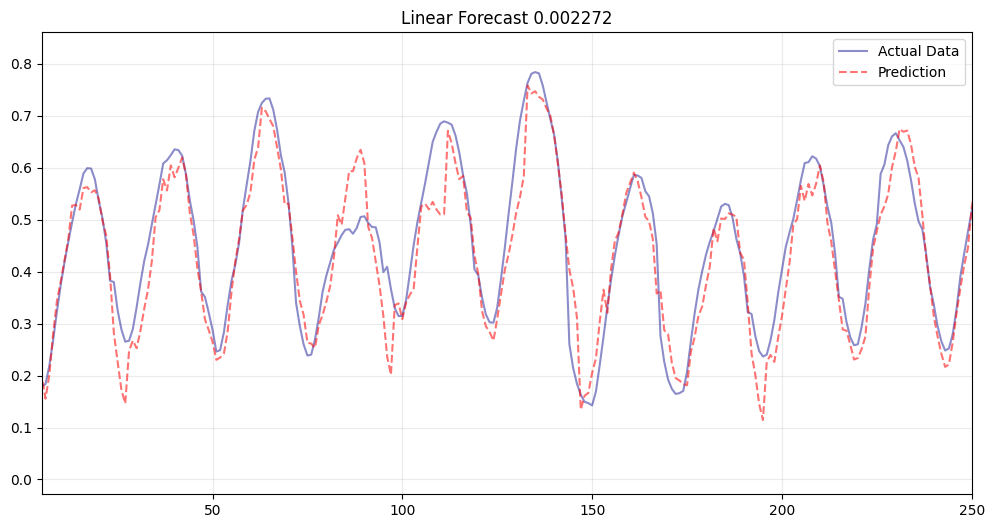

In [20]:
plt.figure(figsize=[12,6])

mse_linear = round(linear_model2.evaluate(test_ds),6)
preds_linear = linear_model2.predict(test_ds).reshape(-1)

plt.plot(y_actual_naive ,color="darkblue", alpha=0.45, label="Actual Data")
plt.plot(preds_linear, "r--", alpha=0.55, label="Prediction")
plt.title(f"Linear Forecast {mse_linear}")
plt.xlim(5,250)
plt.grid(alpha=0.25)
plt.legend()

### Simple RNN model - MSE 0.001674 | -27.28% error compared to linear model

In [21]:
srnn_model = keras.models.Sequential([
    keras.layers.Input(shape=[50, 1]),
    keras.layers.SimpleRNN(32),
    keras.layers.Dense(7)
])
srnn_model.compile(loss="mse", optimizer="adam")
srnn_model.fit(train_ds, validation_data=valid_ds, epochs=50, callbacks=[early_stop, reduce_lr])

Epoch 1/50
379/379 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0296 - val_loss: 0.0053 - learning_rate: 0.0010
Epoch 2/50
379/379 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0049 - val_loss: 0.0036 - learning_rate: 0.0010
Epoch 3/50
379/379 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0035 - val_loss: 0.0031 - learning_rate: 0.0010
Epoch 4/50
379/379 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0030 - val_loss: 0.0031 - learning_rate: 0.0010
Epoch 5/50
379/379 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0028 - val_loss: 0.0029 - learning_rate: 0.0010
Epoch 6/50
379/379 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0027 - val_loss: 0.0029 - learning_rate: 0.0010
Epoch 7/50
379/379 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0026 - val_loss: 0.0027 - learning_rate: 0.0010
Epoch 8/50
379/379 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0026 - val_loss: 0.0027 - learning_rate: 0.0010
Epoch 9/50
379/379 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0025 - val_loss: 0.0029 - learning_rate: 0.0010
Epoch 10/5

81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0017
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


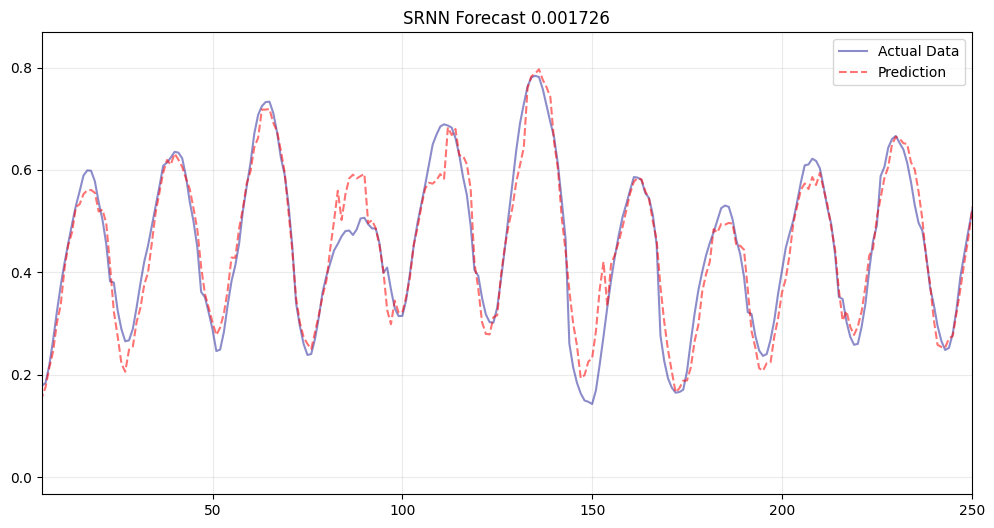

In [22]:
plt.figure(figsize=[12,6])

mse_srnn = round(srnn_model.evaluate(test_ds),6)
preds_srnn = srnn_model.predict(test_ds).reshape(-1)

plt.plot(y_actual_naive ,color="darkblue", alpha=0.45, label="Actual Data")
plt.plot(preds_srnn, "r--", alpha=0.55, label="Prediction")
plt.title(f"SRNN Forecast {mse_srnn}")
plt.xlim(5,250)
plt.grid(alpha=0.25)
plt.legend()

### GRU model - MSE 0.001619 | -3.28% compared to simple RNN

In [23]:
gru_model = keras.models.Sequential([
    keras.layers.Input(shape=[50, 1]),
    keras.layers.GRU(32),
    keras.layers.Dense(7)
])
gru_model.compile(loss="mse", optimizer="adam")
gru_model.fit(train_ds, validation_data=valid_ds, epochs=50, callbacks=[early_stop, reduce_lr])

Epoch 1/50
379/379 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0483 - val_loss: 0.0115 - learning_rate: 0.0010
Epoch 2/50
379/379 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0111 - val_loss: 0.0093 - learning_rate: 0.0010
Epoch 3/50
379/379 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0086 - val_loss: 0.0054 - learning_rate: 0.0010
Epoch 4/50
379/379 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0052 - val_loss: 0.0045 - learning_rate: 0.0010
Epoch 5/50
379/379 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0044 - val_loss: 0.0042 - learning_rate: 0.0010
Epoch 6/50
379/379 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0043 - val_loss: 0.0041 - learning_rate: 0.0010
Epoch 7/50
379/379 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0041 - val_loss: 0.0039 - learning_rate: 0.0010
Epoch 8/50
379/379 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0039 - val_loss: 0.0038 - learning_rate: 0.0010
Epoch 9/50
379/379 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0037 - val_loss: 0.0036 - learning_rate: 0.0010
Epoch 10/5

81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0015
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


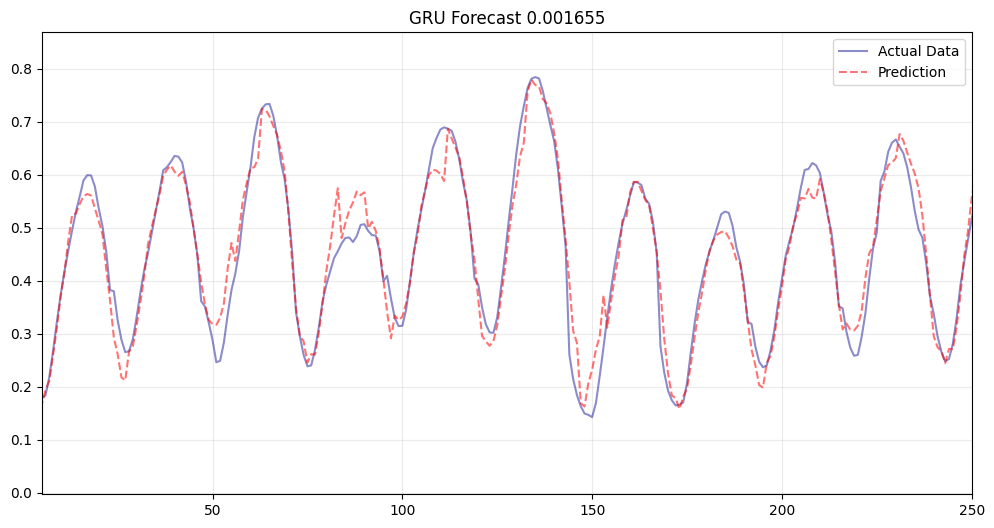

In [24]:
plt.figure(figsize=[12,6])

mse_gru = round(gru_model.evaluate(test_ds),6)
preds_gru = gru_model.predict(test_ds).reshape(-1)

plt.plot(y_actual_naive ,color="darkblue", alpha=0.45, label="Actual Data")
plt.plot(preds_gru, "r--", alpha=0.55, label="Prediction")
plt.title(f"GRU Forecast {mse_gru}")
plt.xlim(5,250)
plt.grid(alpha=0.25)
plt.legend()

### LSTM - MSE 0.001339 | -17.29% compared to GRU

In [25]:
lstm_model = keras.models.Sequential([
    keras.layers.Input(shape=[50, 1]),
    keras.layers.LSTM(32),
    keras.layers.Dense(7)
])

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    patience=4,
    factor=0.5,
    verbose=1,
    min_lr=1e-6
)

optimizer = keras.optimizers.Adam(learning_rate=1e-2)
lstm_model.compile(loss="mse", optimizer=optimizer)
lstm_model.fit(train_ds, validation_data=valid_ds, epochs=50, callbacks=[early_stop, reduce_lr])

Epoch 1/50
379/379 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0189 - val_loss: 0.0042 - learning_rate: 0.0100
Epoch 2/50
379/379 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0040 - val_loss: 0.0034 - learning_rate: 0.0100
Epoch 3/50
379/379 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0025 - val_loss: 0.0024 - learning_rate: 0.0100
Epoch 4/50
379/379 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0022 - val_loss: 0.0028 - learning_rate: 0.0100
Epoch 5/50
379/379 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0023 - val_loss: 0.0025 - learning_rate: 0.0100
Epoch 6/50
379/379 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0020 - val_loss: 0.0025 - learning_rate: 0.0100
Epoch 7/50
379/379 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0020 - val_loss: 0.0022 - learning_rate: 0.0100
Epoch 8/50
379/379 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0019 - val_loss: 0.0023 - learning_rate: 0.0100
Epoch 9/50
379/379 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0018 - val_loss: 0.0024 - learning_rate: 0.0100
Epoch 10/5

81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0012
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


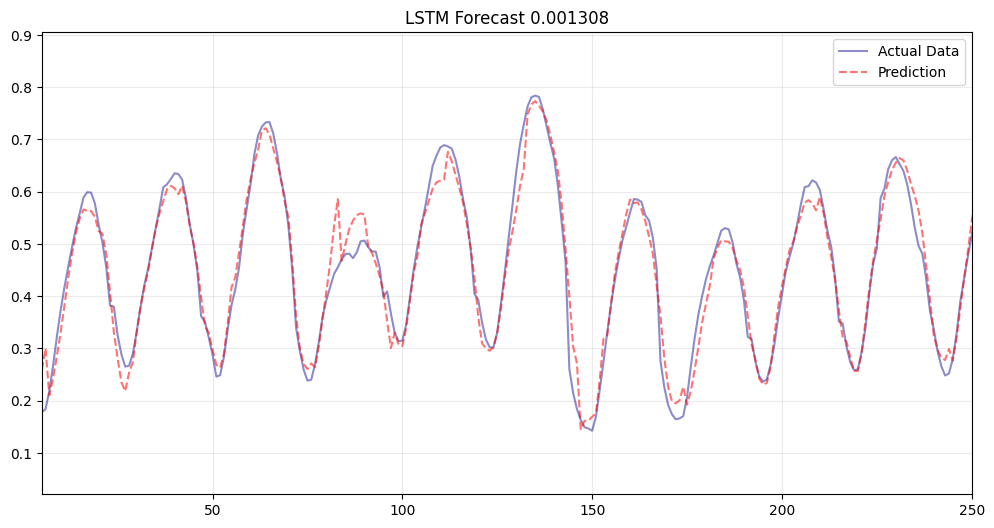

In [26]:
plt.figure(figsize=[12,6])

mse_lstm = round(lstm_model.evaluate(test_ds),6)
preds_lstm = lstm_model.predict(test_ds).reshape(-1)

plt.plot(y_actual_naive ,color="darkblue", alpha=0.45, label="Actual Data")
plt.plot(preds_lstm, "r--", alpha=0.55, label="Prediction")
plt.title(f"LSTM Forecast {mse_lstm}")
plt.xlim(5,250)
plt.grid(alpha=0.25)
plt.legend()

### Deep LSTM model - MSE 0.001058 | -20.98% compared to LSTM

In [27]:
lstm_model1 = keras.models.Sequential([
    keras.layers.Input(shape=[50, 1]),
    keras.layers.LSTM(64, return_sequences=True),
    keras.layers.LSTM(32, return_sequences=True),
    keras.layers.LSTM(32),
    keras.layers.Dense(7)
])

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    patience=4,
    factor=0.5,
    verbose=1,
    min_lr=1e-6
)

optimizer = keras.optimizers.Adam(learning_rate=1e-2)
lstm_model1.compile(loss="mse", optimizer=optimizer)
lstm_model1.fit(train_ds, validation_data=valid_ds, epochs=50, callbacks=[early_stop, reduce_lr])

Epoch 1/50
379/379 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - loss: 0.0252 - val_loss: 0.0043 - learning_rate: 0.0100
Epoch 2/50
379/379 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - loss: 0.0039 - val_loss: 0.0030 - learning_rate: 0.0100
Epoch 3/50
379/379 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - loss: 0.0023 - val_loss: 0.0026 - learning_rate: 0.0100
Epoch 4/50
379/379 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - loss: 0.0021 - val_loss: 0.0020 - learning_rate: 0.0100
Epoch 5/50
379/379 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - loss: 0.0019 - val_loss: 0.0021 - learning_rate: 0.0100
Epoch 6/50
379/379 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - loss: 0.0019 - val_loss: 0.0020 - learning_rate: 0.0100
Epoch 7/50
379/379 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - loss: 0.0019 - val_loss: 0.0021 - learning_rate: 0.0100
Epoch 8/50
377/379 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0017
Epoch 8: ReduceLROnPlateau reducing learning rate to 0.004999999888241291.
379/379 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - loss: 0.0017 - val_loss: 0.0021 - l

81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0010 
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


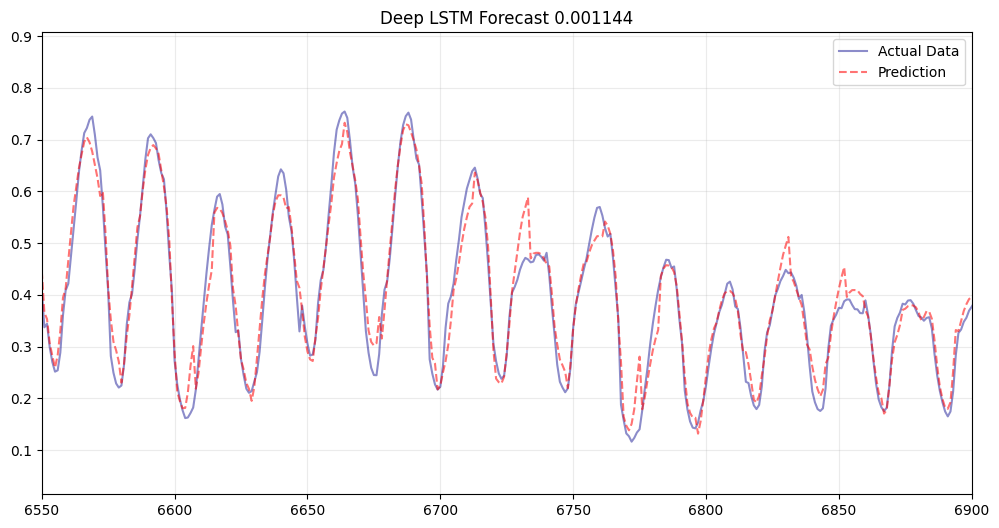

In [28]:
plt.figure(figsize=[12,6])

mse_deep = round(lstm_model1.evaluate(test_ds),6)
preds_deep = lstm_model1.predict(test_ds).reshape(-1)

plt.plot(y_actual_naive ,color="darkblue", alpha=0.45, label="Actual Data")
plt.plot(preds_deep, "r--", alpha=0.55, label="Prediction")
plt.title(f"Deep LSTM Forecast {mse_deep}")
plt.xlim(6550,6900)
plt.grid(alpha=0.25)
plt.legend()

## 3. Predicting next 7 days with stride of 1

In [29]:
steps_in = 50
steps_out = 7
total_window_size = steps_in + steps_out 

# 1. Create a dataset of 57-step windows
base_ds_train_dense = tf.keras.utils.timeseries_dataset_from_array(
    data=train_scaled,
    targets=None,
    sequence_length=total_window_size,
    sequence_stride=1,
    shuffle=True,
    batch_size=32
)

base_ds_valid_dense = tf.keras.utils.timeseries_dataset_from_array(
    data=valid_scaled,
    targets=None,
    sequence_length=total_window_size,
    sequence_stride=1,
    shuffle=False,
    batch_size=32
)

base_ds_test_dense = tf.keras.utils.timeseries_dataset_from_array(
    data=test_scaled,
    targets=None,
    sequence_length=total_window_size,
    sequence_stride=1,
    shuffle=False,
    batch_size=32
)

# 2. Split each batch into X (first 50 steps) and y (next 7 steps)
def split_window(window):
    x = window[:, :steps_in, :]
    y = window[:, steps_in:, :]
    return x, y

train_ds_dense = base_ds_train_dense.map(split_window)
valid_ds_dense = base_ds_valid_dense.map(split_window)
test_ds_dense = base_ds_test_dense.map(split_window)

### Deep LSTM model on dense dataset - MSE 0.000814 | -23.06% compared to Deep LSTM stride 7

In [30]:
lstm_model1 = keras.models.Sequential([
    keras.layers.Input(shape=[50, 1]),
    keras.layers.LSTM(64, return_sequences=True),
    keras.layers.LSTM(32, return_sequences=True),
    keras.layers.LSTM(32),
    keras.layers.Dense(7)
])

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    patience=4,
    factor=0.5,
    verbose=1,
    min_lr=1e-6
)

optimizer = keras.optimizers.Adam(learning_rate=1e-2)
lstm_model1.compile(loss="mse", optimizer=optimizer, metrics=["mae"])
lstm_model1.fit(train_ds_dense, validation_data=valid_ds_dense, epochs=50, callbacks=[early_stop, reduce_lr])

Epoch 1/50
2652/2652 ━━━━━━━━━━━━━━━━━━━━ 63s 23ms/step - loss: 0.0074 - mae: 0.0576 - val_loss: 0.0018 - val_mae: 0.0314 - learning_rate: 0.0100
Epoch 2/50
2652/2652 ━━━━━━━━━━━━━━━━━━━━ 61s 23ms/step - loss: 0.0017 - mae: 0.0298 - val_loss: 0.0015 - val_mae: 0.0274 - learning_rate: 0.0100
Epoch 3/50
2652/2652 ━━━━━━━━━━━━━━━━━━━━ 61s 23ms/step - loss: 0.0014 - mae: 0.0270 - val_loss: 0.0015 - val_mae: 0.0276 - learning_rate: 0.0100
Epoch 4/50
2652/2652 ━━━━━━━━━━━━━━━━━━━━ 61s 23ms/step - loss: 0.0012 - mae: 0.0247 - val_loss: 0.0012 - val_mae: 0.0238 - learning_rate: 0.0100
Epoch 5/50
2652/2652 ━━━━━━━━━━━━━━━━━━━━ 61s 23ms/step - loss: 0.0011 - mae: 0.0236 - val_loss: 0.0012 - val_mae: 0.0251 - learning_rate: 0.0100
Epoch 6/50
2652/2652 ━━━━━━━━━━━━━━━━━━━━ 61s 23ms/step - loss: 0.0010 - mae: 0.0227 - val_loss: 0.0011 - val_mae: 0.0220 - learning_rate: 0.0100
Epoch 7/50
2652/2652 ━━━━━━━━━━━━━━━━━━━━ 61s 23ms/step - loss: 9.5293e-04 - mae: 0.0216 - val_loss: 0.0011 - val_mae: 0.022

81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 7.4772e-04 - mae: 0.0185
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


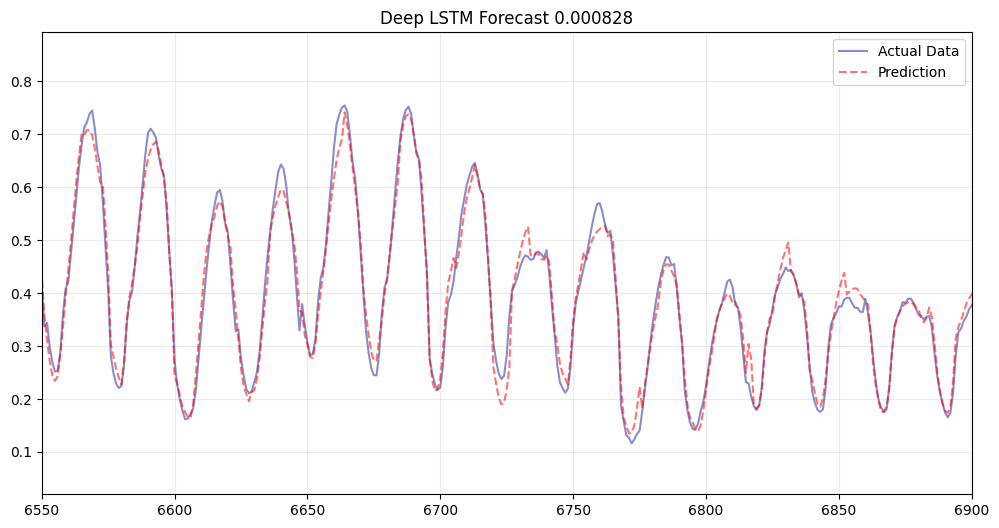

In [124]:
plt.figure(figsize=[12,6])

mse_deep = round(lstm_model1.evaluate(test_ds)[0],6)
preds_deep = lstm_model1.predict(test_ds).reshape(-1)

plt.plot(y_actual_naive ,color="darkblue", alpha=0.45, label="Actual Data")
plt.plot(preds_deep, "r--", alpha=0.55, label="Prediction")
plt.title(f"Deep LSTM Forecast {mse_deep}")
plt.xlim(6550,6900)
plt.grid(alpha=0.25)
plt.legend()

## 4. Predicting on unseen data for different electricity provider

### Predicting for unseen American Electric Power data MSE 0.000814

In [32]:
aep = pd.read_csv("data/AEP_hourly.csv")
aep = aep.drop(columns=["Datetime"])

In [33]:
n_aep = len(aep)

train_df_aep = dayton.iloc[:int(n_aep*0.5)]
val_df_aep = dayton.iloc[int(n_aep*0.5):int(n_aep*0.85)]
test_df_aep = dayton.iloc[int(n_aep*0.85):]

scaler_aep = MinMaxScaler()

train_scaled_aep = scaler_aep.fit_transform(train_df_aep)
valid_scaled_aep = scaler_aep.transform(val_df_aep)
test_scaled_aep = scaler_aep.transform(test_df_aep)

In [34]:
steps_in = 50
steps_out = 7
total_window_size = steps_in + steps_out 

# 1. Create a dataset of 57-step windows
aep_ds_train = tf.keras.utils.timeseries_dataset_from_array(
    data=train_scaled_aep,
    targets=None,
    sequence_length=total_window_size,
    sequence_stride=7,
    shuffle=True,
    batch_size=32
)

aep_ds_valid = tf.keras.utils.timeseries_dataset_from_array(
    data=valid_scaled_aep,
    targets=None,
    sequence_length=total_window_size,
    sequence_stride=7,
    shuffle=False,
    batch_size=32
)

aep_ds_test = tf.keras.utils.timeseries_dataset_from_array(
    data=test_scaled_aep,
    targets=None,
    sequence_length=total_window_size,
    sequence_stride=7,
    shuffle=False,
    batch_size=32
)

# 2. Split each batch into X (first 50 steps) and y (next 7 steps)
def split_window(window):
    x = window[:, :steps_in, :]
    y = window[:, steps_in:, :]
    return x, y

train_ds_aep = aep_ds_train.map(split_window)
valid_ds_aep = aep_ds_valid.map(split_window)
test_ds_aep = aep_ds_test.map(split_window)

In [35]:
y_actual_test_aep = []

for x, y in test_ds_aep:
    y_actual_test_aep.append(y.numpy())

# Stack all batches along the batch dimension (axis 0)
y_actual_test_aep = np.concatenate(y_actual_test_aep, axis=0).reshape(-1)



2026-09-16 09:06:32.320936: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 7.5465e-04 - mae: 0.0186


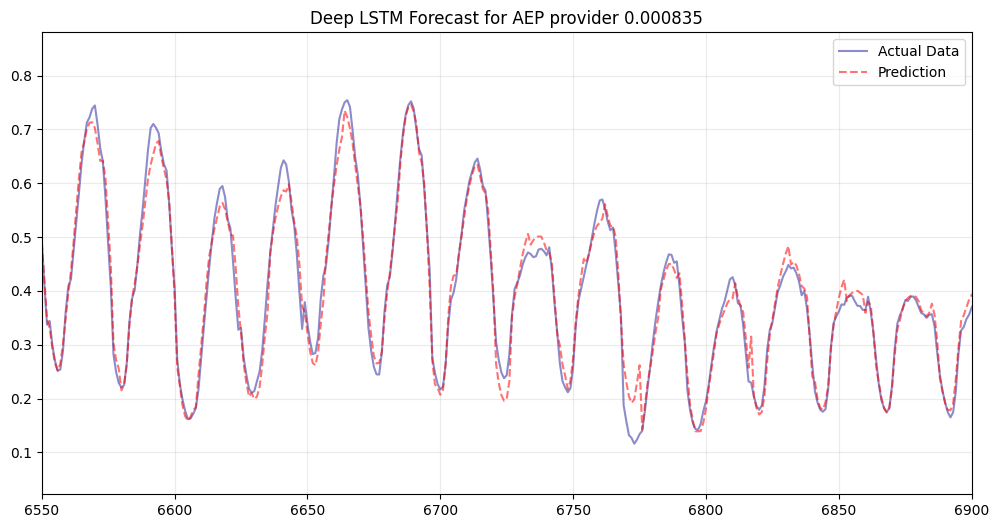

In [36]:
plt.figure(figsize=[12,6])
y_aep_test = lstm_model1.predict(test_ds_aep).reshape(-1)
mse_aep = round(lstm_model1.evaluate(test_ds_aep)[0], 6)


plt.plot(y_actual_test_aep,color="darkblue", alpha=0.45, label="Actual Data")
plt.plot(y_aep_test, "r--", alpha=0.55, label="Prediction")
plt.title(f"Deep LSTM Forecast for AEP provider {mse_aep}")
plt.xlim(6550,6900)
plt.grid(alpha=0.25)
plt.legend()

# 5. Plots

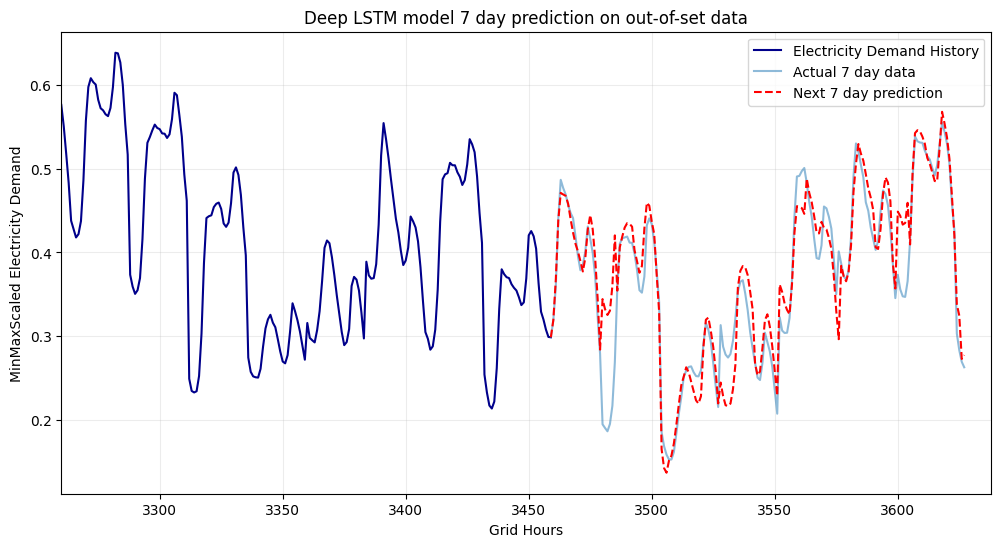

In [114]:
start_step = 3460
finish_step = 3628
starting_t = 3260

steps_pred = np.arange(start_step-1, finish_step, 1)
steps_actual = np.arange(starting_t,start_step)

plt.figure(figsize=[12,6])
plt.plot(steps_actual,y_actual_test_aep[starting_t:start_step], color="darkblue", label="Electricity Demand History")
plt.plot(steps_pred, y_actual_test_aep[start_step-1:finish_step], alpha=0.5, label="Actual 7 day data")
plt.plot(steps_pred,y_aep_test[start_step-1:finish_step], "--", color="red", label="Next 7 day prediction")
plt.title("Deep LSTM model 7 day prediction on out-of-set data")
plt.xlabel("Grid Hours")
plt.ylabel("MinMaxScaled Electricity Demand")
plt.grid(alpha=0.23)
plt.xlim(starting_t, finish_step + 10)
plt.legend()

# 6. Model explainability with SHAP

In [159]:
import shap

# train samples
X_background_list = []
for x_batch, _ in train_ds.take(5):  # 5 batches * 32 samples = 160 samples
    X_background_list.append(x_batch.numpy())

X_background = np.concatenate(X_background_list, axis=0)

# test samples
X_test_list = []
for x_batch, _ in test_ds.take(2):
    X_test_list.append(x_batch.numpy())

X_test = np.concatenate(X_test_list, axis=0)[:50]  # Explain first 20 windows

2026-09-18 16:14:33.402298: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-09-18 16:14:33.427014: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [161]:
# If your outputs (batch, 7, n_features), explain a specific step ahead (step 0 = t+1)
target_step = 0  # 0 corresponds to the first predicted step (t+1), up to 6 for (t+7)

# Wrap model prediction for that single forecast step
def predict_step(x):
    # Returns (batch, n_features) or (batch, 1)
    preds = lstm_model1(x)
    return preds[:, target_step, :]

# Initialize GradientExplainer
explainer = shap.GradientExplainer(lstm_model1, X_background)

# Calculate SHAP values for test samples
# shap_values shape: (num_samples, 50, num_features)
shap_values = explainer.shap_values(X_test)

/Users/homelab/Desktop/deep_learning/dl_env/lib/python3.9/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_28
Received: inputs=['Tensor(shape=(50, 50, 1))']
  warnings.warn(msg)


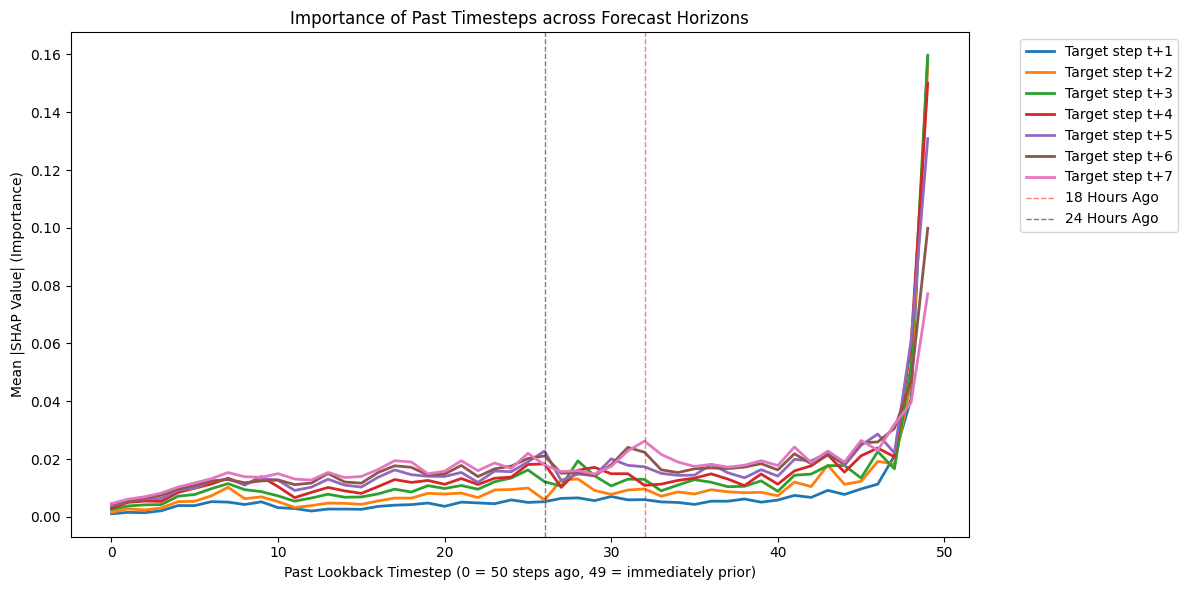

In [189]:
# shap_values shape: (20, 50, 1, 7)
# Average the absolute SHAP values across all 20 test samples and drop the feature axis
# Result shape: (50, 7)
mean_abs_shap = np.mean(np.abs(shap_values), axis=0).squeeze()  # shape: (50, 7)

plt.figure(figsize=(12, 6))
for h in np.arange(0,7,1):
    plt.plot(range(50), mean_abs_shap[:, h], label=f"Target step t+{h+1}", lw=2)

plt.axvline(50-18, alpha=0.5, color="red", linestyle="--", lw=1, label="18 Hours Ago")
plt.axvline(50-24, alpha=0.5, color="black", linestyle="--", lw=1, label="24 Hours Ago")
plt.xlabel("Past Lookback Timestep (0 = 50 steps ago, 49 = immediately prior)")
plt.ylabel("Mean |SHAP Value| (Importance)")
plt.title("Importance of Past Timesteps across Forecast Horizons")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

2 observations:
- For every t+n prediction the strongest influence comes from the previous five days, where the current day demand dominates everything.
- As the predictions gets farther into the future (t+7), the influence of the features distributes better than compared to next day prediction (t+1). It is visible that the blue line lower compared to the pink line, which indicates t+7 prediction relies more on previous timesteps data.

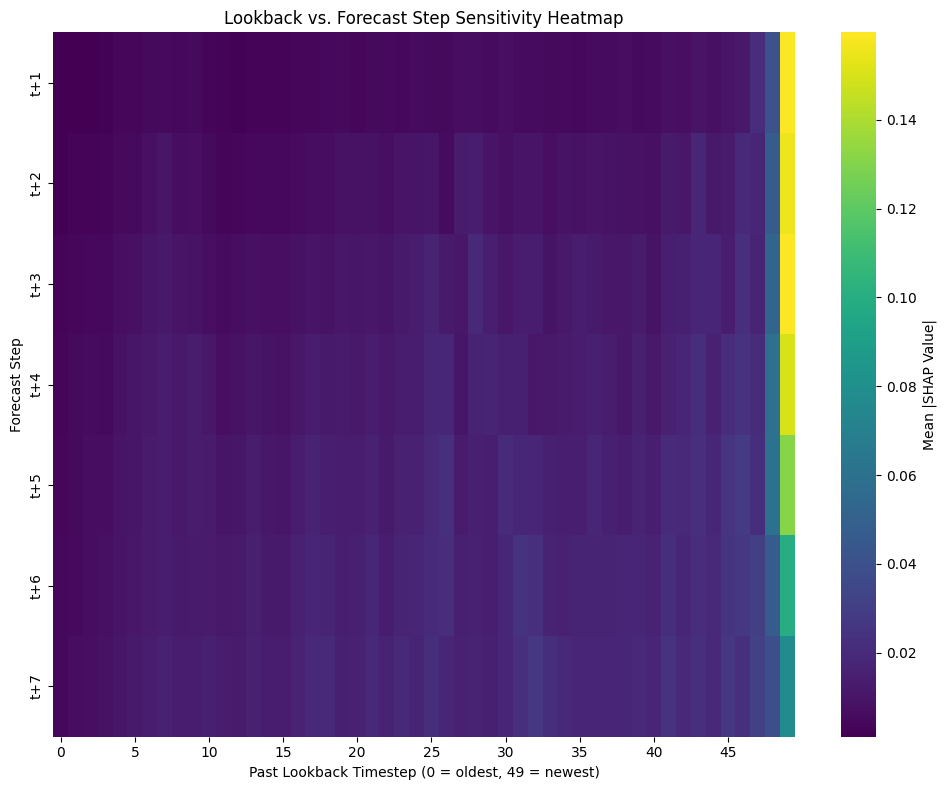

In [193]:
import seaborn as sns

plt.figure(figsize=(10, 8))
# mean_abs_shap is (50, 7). Transpose to (7, 50) so rows are horizons
sns.heatmap(
    mean_abs_shap.T,
    cmap="viridis",
    xticklabels=5,  # mark every 5th lookback step
    yticklabels=[f"t+{h+1}" for h in range(7)],
    cbar_kws={'label': 'Mean |SHAP Value|'}
)
plt.xlabel("Past Lookback Timestep (0 = oldest, 49 = newest)")
plt.ylabel("Forecast Step")
plt.title("Lookback vs. Forecast Step Sensitivity Heatmap")
plt.tight_layout()
plt.show()

Clear heatmap of the feature importance for every prediction timeframe

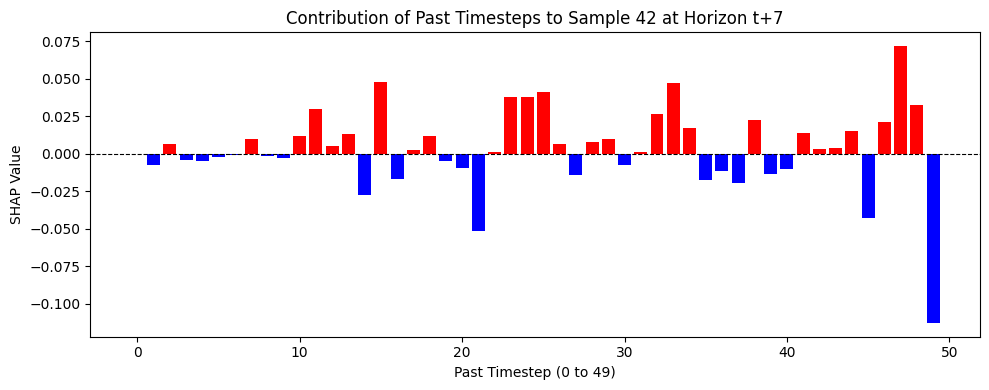

In [225]:
sample_idx = 42
target_step = 6  # 0 corresponds to t+1

# Extract for sample 0, feature 0, target step 0 -> 1D array of 50 values
sample_shap = shap_values[sample_idx, :, 0, target_step]

plt.figure(figsize=(10, 4))
colors = ['red' if val > 0 else 'blue' for val in sample_shap]
plt.bar(range(50), sample_shap, color=colors, width=0.8)
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.xlabel("Past Timestep (0 to 49)")
plt.ylabel("SHAP Value")
plt.title(f"Contribution of Past Timesteps to Sample {sample_idx} at Horizon t+{target_step+1}")
plt.tight_layout()
plt.show()

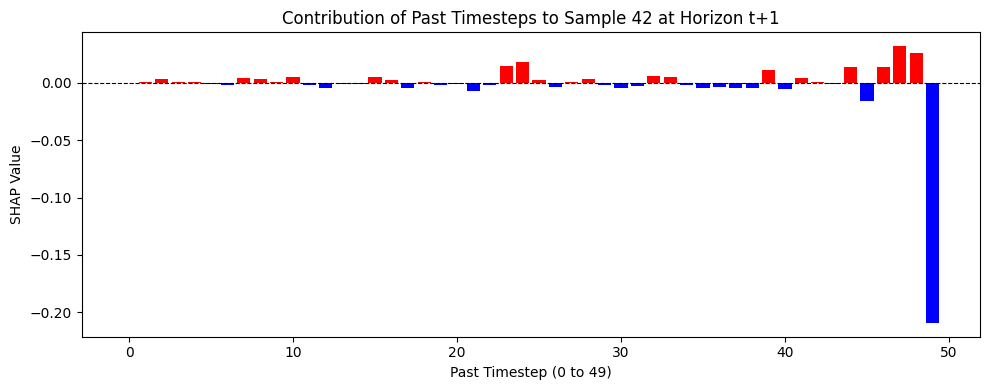

This plot represent the feature contribution for a single instance predicting t+7. (Top plot) Compared to predicting the next day t+1, (bottom part) it is much more distributed, values several hours ago have much more influence than the bottom plot.

### Built-in plots

In [ ]:
# train samples
X_background_list = []
for x_batch, _ in train_ds.take(5):  # 5 batches * 32 samples = 160 samples
    X_background_list.append(x_batch.numpy())

X_background = np.concatenate(X_background_list, axis=0)

# test samples
X_test_list = []
for x_batch, _ in test_ds.take(2):
    X_test_list.append(x_batch.numpy())

X_test = np.concatenate(X_test_list, axis=0)[:50]  # Explain first 20 windows

In [222]:
h = 0

sv_horizon = shap_values[:, :, 0, h]
X_test_2d = X_test[:, :, 0]
feature_names = [f"t-{50 - 1 - i}" for i in range(50)]

/var/folders/96/y_b89w8x28n8_1srx31m7c5m0000gn/T/ipykernel_40643/796252508.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


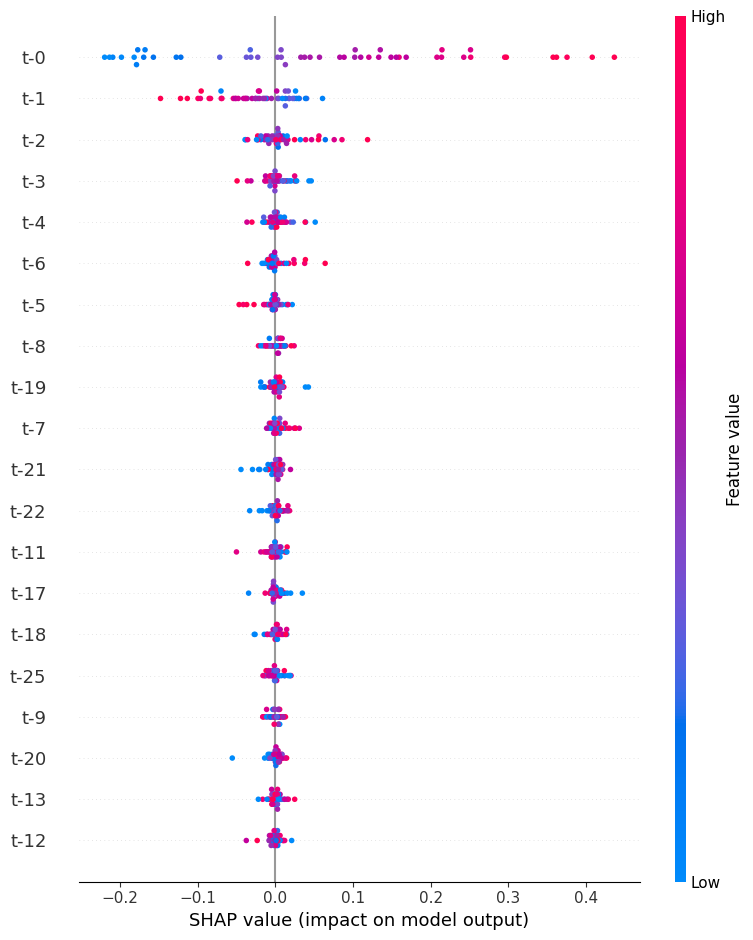

In [223]:
# Beeswarm plot showing which past timesteps drive predictions up/down
shap.summary_plot(
    sv_horizon, 
    features=X_test_2d, 
    feature_names=feature_names
)

For the next day prediction the most important features are the current day and the past 5 days. However if the model needs to predict where will the demand be at t+7 then its not this clear. Almost every timestep has influence on that prediction.

/var/folders/96/y_b89w8x28n8_1srx31m7c5m0000gn/T/ipykernel_40643/3973949159.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


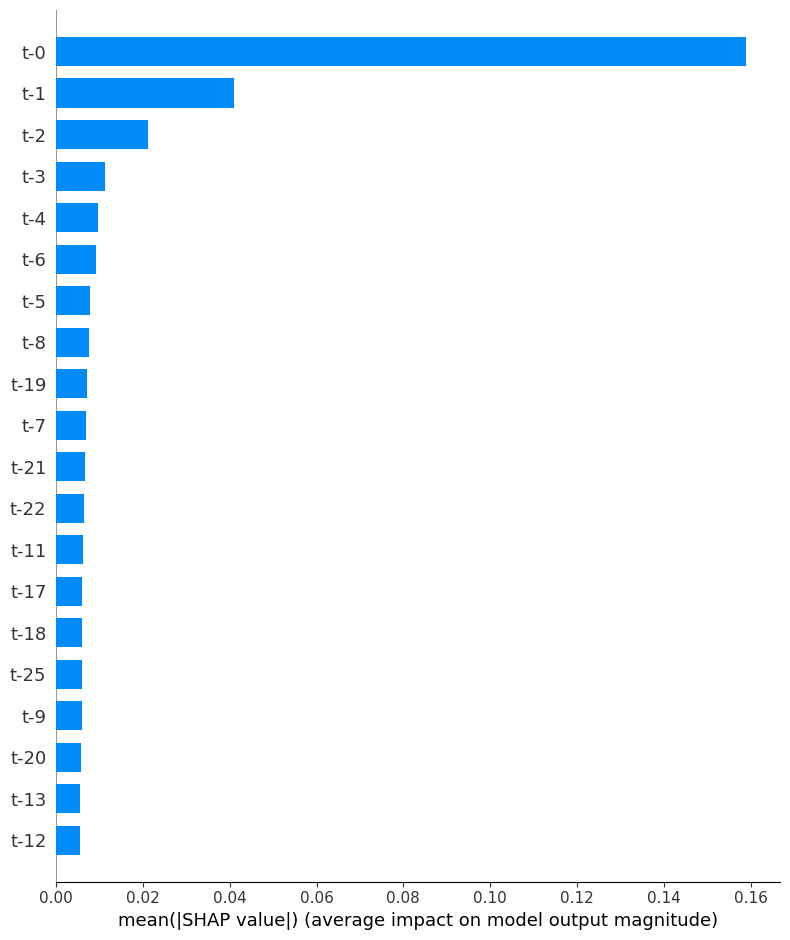

In [219]:
# Bar plot showing overall global importance of past timesteps
shap.summary_plot(
    sv_horizon, 
    features=X_test_2d, 
    feature_names=feature_names, 
    plot_type="bar"
)

This plot is the same as the above but in absolute terms.